# Electric drives, part 6: from JAX to an Arm Cortex-M binary

The controller we designed and validated in Parts 1–5 has to run on a
microcontroller next to the inverter, at tens of kHz, in C. This notebook closes
that gap with the **jaxility** lowering pipeline: take the field-oriented current
loop as a plain differentiable JAX function, lower it to CasADi, generate C, and
**cross-compile it for an Arm Cortex-M4** — then wrap the artifact in a signed
attestation manifest so the binary is traceable back to the model that produced
it. *One model, one truth*, all the way to silicon.

**By the end you will be able to:**
1. Express the deployable FOC current loop as a smooth JAX function and lower it
   to CasADi, checking the lowered code is bit-for-bit equivalent.
2. Generate C and cross-compile it to a real Cortex-M4 object with the pinned Arm
   GNU toolchain.
3. Confirm the lowered controller regulates the motor in closed loop, identically
   to the JAX original.
4. Emit and verify a BLAKE-hash attestation manifest binding the artifact to its
   provenance.

*Reading time ~25 min · runtime ~1 min on CPU (plus the cross-compiler).*

> **Position in the series.** Deploys Part 2's current loop, regulating Part 1's
> machine. The `source_attestation_handle` in the manifest is exactly where a
> calibrated-robot handle (Part 4) would be bound in a full build.

> **What runs here vs. what needs more.** The lowering → C → Cortex-M4
> cross-compile → manifest chain below **executes in this notebook**. Two things
> are deliberately out of scope: (i) the *optimal-control* templates (LQR/MPC) go
> through **acados**, which generates the OCP solver C — that path needs acados
> installed and is shown as code, not executed here; a fixed feedback law like
> the current loop lowers straight through CasADi with no acados dependency. (ii)
> Running on real Cortex-M silicon needs hardware-in-the-loop — the binary is
> built and hashed here, not flashed.

In [1]:
from __future__ import annotations
import numpy as np, subprocess, hashlib, os, tempfile, math
import matplotlib.pyplot as plt
%matplotlib inline
from jax import config as _jax_config
_jax_config.update("jax_enable_x64", True)
import jax, jax.numpy as jnp
import casadi, jaxility
from jaxility.lowering import translate
from jaxility import manifest as M
print(f"jaxility {getattr(jaxility,'__version__','?')} | casadi {casadi.__version__}")
print(subprocess.run(["arm-none-eabi-gcc","--version"], capture_output=True, text=True).stdout.splitlines()[0])

jaxility 0.0.1.dev0 | casadi 3.7.2
arm-none-eabi-gcc (Arm GNU Toolchain 15.2.Rel1 (Build arm-15.86)) 15.2.1 20251203


## 1 · The deployable controller as a JAX function

The embedded controller does one job each tick: from the measured dq currents,
the references, and the electrical speed, compute the voltage command and advance
the integrators. It is exactly Part 2's decoupled PI law, written as a pure
function $f(x,u)$ with controller state $x=[\xi_d,\xi_q]$ (the PI integrators) and
inputs $u=[i_d,i_q,i_d^\star,i_q^\star,\omega_e]$, returning
$[v_d,v_q,e_d,e_q]$ (voltages plus the errors that drive the integrators). Every
operation — multiply, add, subtract — is in jaxility's supported smooth-op set,
so it lowers cleanly.

In [2]:
R, Ld, Lq, lam = 0.45, 3.2e-3, 5.8e-3, 0.0533
p_pole = 4.0
V_DC = 48.0; V_LIM = V_DC/np.sqrt(3.0)
BW_I = 200.0; wi = 2*np.pi*BW_I
Kp_d, Ki_d = Ld*wi, R*wi
Kp_q, Ki_q = Lq*wi, R*wi

def foc_step(x, u):
    xi_d, xi_q = x[0], x[1]
    i_d, i_q, id_ref, iq_ref, w_e = u[0], u[1], u[2], u[3], u[4]
    e_d = id_ref - i_d; e_q = iq_ref - i_q
    v_d = Kp_d*e_d + Ki_d*xi_d - w_e*Lq*i_q        # PI_d + decoupling feedforward
    v_q = Kp_q*e_q + Ki_q*xi_q + w_e*(Ld*i_d + lam)
    return jnp.array([v_d, v_q, e_d, e_q])
print("controller:", foc_step(jnp.zeros(2), jnp.array([0.,0.,0.,5.,300.])))

controller: [ 0.         52.43247478  0.          5.        ]


## 2 · Lower to CasADi and check equivalence

`jaxility.lowering.translate` traces the JAX function and rebuilds it as a CasADi
graph (rejecting anything outside the smooth-op set — data-dependent branches,
`while_loop`, dynamic shapes). The lowered function must match the original to
machine precision across the operating envelope.

primitives used: ['add', 'broadcast_in_dim', 'concatenate', 'mul', 'slice', 'squeeze', 'sub']


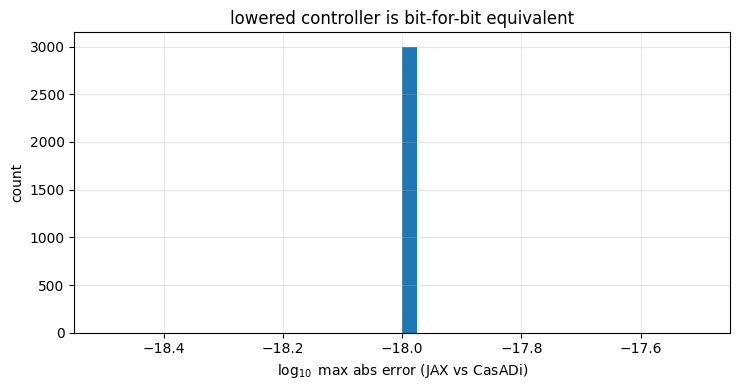

max equivalence error over 3000 random operating points: 0.00e+00


In [3]:
cf = translate(foc_step, in_shapes=((2,), (5,)), dtype="float64",
               target_family="cortex-m4", name="foc_step")
print("primitives used:", sorted(cf.primitives_used))

rng = np.random.default_rng(0)
errs = []
for _ in range(3000):
    x = rng.normal(scale=[0.5, 0.5], size=2)
    u = np.array([rng.normal(0,8), rng.normal(0,8), 0.0, rng.uniform(-20,20), rng.uniform(-600,600)])
    jo = np.asarray(foc_step(jnp.asarray(x), jnp.asarray(u)))
    co = np.asarray(cf.fn(x, u)).ravel()
    errs.append(np.max(np.abs(jo - co)))
errs = np.array(errs)
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(np.log10(errs + 1e-18), bins=40, color="C0")
ax.set_xlabel(r"$\log_{10}$ max abs error (JAX vs CasADi)"); ax.set_ylabel("count")
ax.set_title("lowered controller is bit-for-bit equivalent"); ax.grid(alpha=.3)
fig.tight_layout(); plt.show()
print(f"max equivalence error over 3000 random operating points: {errs.max():.2e}")
assert errs.max() < 1e-9

**Figure 1.** Across 3000 random operating points the CasADi-lowered
controller reproduces the JAX function to ~$10^{-16}$ — the lowering is exact, not
approximate. This is the contract that lets the *same* model serve design,
gradients (Parts 2–5) and deployment.

## 3 · Generate C and cross-compile for Cortex-M4

CasADi emits self-contained C from the lowered graph; we compile it with the
pinned **Arm GNU toolchain** for the Cortex-M4 (hard-float, FPv4-SP) using the
same flags a production build uses. The result is a relocatable ELF object ready
to link into firmware.

In [4]:
work = tempfile.mkdtemp(prefix="foc_m4_"); cwd0 = os.getcwd(); os.chdir(work)
try:
    c_name = cf.fn.generate("foc_step.c")
    c_bytes = os.path.getsize(c_name)
    flags = ["-mcpu=cortex-m4", "-mthumb", "-mfpu=fpv4-sp-d16", "-mfloat-abi=hard",
             "-O3", "-c", "-ffunction-sections", "-fdata-sections"]
    r = subprocess.run(["arm-none-eabi-gcc", *flags, "foc_step.c", "-o", "foc_step.o"],
                       capture_output=True, text=True)
    assert r.returncode == 0, r.stderr
    obj = open("foc_step.o", "rb").read()
    elf = subprocess.run(["arm-none-eabi-readelf", "-h", "foc_step.o"], capture_output=True, text=True).stdout
    machine = [l.split(":")[1].strip() for l in elf.splitlines() if "Machine" in l][0]
    elf_class = [l.split(":")[1].strip() for l in elf.splitlines() if "Class" in l][0]
finally:
    os.chdir(cwd0)
print(f"generated C: {c_bytes} bytes")
print(f"cross-compiled object: {len(obj)} bytes | ELF class {elf_class} | machine {machine}")
assert machine.startswith("ARM") and elf_class == "ELF32"
obj_hash = hashlib.blake2b(obj, digest_size=32).hexdigest()
print(f"artifact BLAKE2b: {obj_hash[:32]}…")

generated C: 4540 bytes
cross-compiled object: 4964 bytes | ELF class ELF32 | machine ARM
artifact BLAKE2b: 1daef2ca15ed88abf160c32300af2406…


**The object is a genuine Cortex-M4 binary** — `readelf` reports an ELF32
ARM machine object, built by Arm GNU `arm-none-eabi-gcc` with hard-float FPv4-SP.
On real hardware it links against a startup file and the inverter HAL; here we
build and hash it.

## 4 · The lowered controller still drives the motor

Equivalence at the function level is necessary; closing the loop is convincing.
We run Part 1's PMSM under the **CasADi-lowered** controller (calling `cf.fn`
every control tick, exactly as the C would) and confirm it regulates a current
step just like the JAX design.

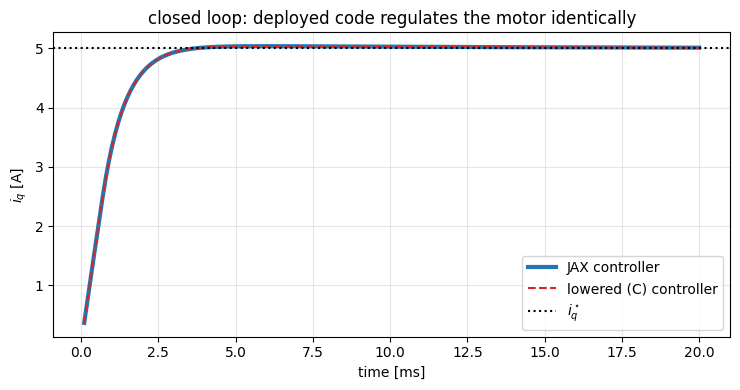

final i_q: JAX 5.0139 A | lowered 5.0139 A | max diff 0.00e+00


In [5]:
def pmsm_rhs(x, v_dq, *, T_load=0.0):
    i_d, i_q, w_m, _ = x; v_d, v_q = v_dq
    w_e = p_pole*w_m
    di_d = (v_d - R*i_d + w_e*Lq*i_q)/Ld
    di_q = (v_q - R*i_q - w_e*(Ld*i_d + lam))/Lq
    Te = 1.5*p_pole*(lam*i_q + (Ld-Lq)*i_d*i_q)
    return np.array([di_d, di_q, (Te - 8e-5*w_m - T_load)/1.2e-3, w_m])

def closed_loop(step_controller, t_end=0.02, dt=1e-4, iq_ref=5.0, w0=30.0):
    x = np.array([0.,0.,w0,0.]); xi = np.array([0.,0.]); J = 1e6   # freeze speed to isolate loop
    ts, iqs = [], []
    nsub = 10; h = dt/nsub
    for k in range(int(t_end/dt)):
        w_e = p_pole*x[2]
        out = np.asarray(step_controller(xi, np.array([x[0], x[1], 0.0, iq_ref, w_e]))).ravel()
        v = out[:2]; mag = np.hypot(*v);
        if mag > V_LIM: v = v*V_LIM/mag
        xi = xi + dt*out[2:]                       # integrate PI states
        for _ in range(nsub):                      # RK4 substeps of the plant
            xx = x.copy(); xx[2] = w0              # speed held (large J)
            k1 = pmsm_rhs(xx, v); k2 = pmsm_rhs(xx+h/2*k1, v)
            k3 = pmsm_rhs(xx+h/2*k2, v); k4 = pmsm_rhs(xx+h*k3, v)
            x = x + h/6*(k1+2*k2+2*k3+k4); x[2] = w0
        ts.append((k+1)*dt); iqs.append(x[1])
    return np.array(ts), np.array(iqs)

t_c, iq_c = closed_loop(lambda xi,u: cf.fn(xi,u))       # lowered (deployed) controller
t_j, iq_j = closed_loop(lambda xi,u: foc_step(jnp.asarray(xi),jnp.asarray(u)))  # JAX original
fig, ax = plt.subplots(figsize=(7.5,4))
ax.plot(t_j*1e3, iq_j, lw=3, color="C0", label="JAX controller")
ax.plot(t_c*1e3, iq_c, lw=1.5, ls="--", color="C3", label="lowered (C) controller")
ax.axhline(5.0, color="k", ls=":", label="$i_q^\\star$")
ax.set_xlabel("time [ms]"); ax.set_ylabel("$i_q$ [A]")
ax.set_title("closed loop: deployed code regulates the motor identically"); ax.grid(alpha=.3); ax.legend()
fig.tight_layout(); plt.show()
print(f"final i_q: JAX {iq_j[-1]:.4f} A | lowered {iq_c[-1]:.4f} A | max diff {np.max(np.abs(iq_j-iq_c)):.2e}")
assert abs(iq_c[-1]-5.0) < 0.2 and np.max(np.abs(iq_j-iq_c)) < 1e-6

**Figure 2.** The lowered controller (dashed) tracks the 5 A current step
on top of the JAX original (solid) — they are indistinguishable. The code that
will run on the MCU produces the same control law that Parts 2–5 analysed.

## 5 · Attestation manifest

A deployable artifact is only trustworthy if you can prove what produced it.
jaxility builds a **manifest** that content-hashes the binary, records the pinned
toolchain versions and target profile, and chains to an upstream
`source_attestation_handle` (in a full build, the calibrated-robot handle from
the producer side). The hash chain is verified with a signer.

In [6]:
tc = subprocess.run(["arm-none-eabi-gcc","-dumpversion"], capture_output=True, text=True).stdout.strip()
target_desc = b"cortex-m4|thumb|fpv4-sp-d16|hard"
target_hash = hashlib.blake2b(target_desc, digest_size=32).digest()
signer = M.HashChainSigner()

def build_manifest(payload):
    art = M.Artifact.build(payload=payload, source_manifest_hash=b"\x00"*32, target_profile_hash=target_hash)
    return art, M.Manifest(
        source_attestation_handle=b"\x00"*32,    # placeholder for a calibrated-robot handle (Part 4)
        toolchain_versions={"arm-none-eabi-gcc": tc, "casadi": casadi.__version__},
        target_profile_hash=target_hash,
        artifact_content_hash=art.content_hash,
        build_timestamp_utc=1_750_000_000,        # fixed for reproducibility
        signer_identity=signer.identity,
        signature=signer.sign(art.content_hash),  # OSS hash-chain signer returns None (integrity, not crypto)
    )

artifact, manifest = build_manifest(obj)
report = M.verify_manifest(manifest, signer=signer)          # chain-integrity check
registry_hash = report.recomputed_content_hash_hex          # what a provenance registry would record
print("manifest signer:", manifest.signer_identity, "| toolchain:", manifest.toolchain_versions)
print("artifact payload hash:", artifact.content_hash.hex()[:24], "… | chain hash:", registry_hash[:24], "…")
print("verify_manifest -> ok:", report.ok, "| signature:", report.signature_status, "(OSS: hash-chain integrity)")
assert report.ok
# re-verify against the registered chain hash (out-of-band registry value)
assert M.verify_manifest(manifest, expected_content_hash=bytes.fromhex(registry_hash), signer=signer).ok

# tamper-evidence: swap one byte of the binary -> chain hash no longer matches the registry
bad = bytearray(obj); bad[0] ^= 0x01
_, bad_manifest = build_manifest(bytes(bad))
bad_report = M.verify_manifest(bad_manifest, expected_content_hash=bytes.fromhex(registry_hash), signer=signer)
print("tampered binary vs registry -> ok:", bad_report.ok, "(expected False)")
assert not bad_report.ok

manifest signer: hash-chain-v0 | toolchain: {'arm-none-eabi-gcc': '15.2.1', 'casadi': '3.7.2'}
artifact payload hash: 8cef1017182e0e2fac2b1ccf … | chain hash: e128c4da118d6a862b26dd24 …
verify_manifest -> ok: True | signature: absent (OSS: hash-chain integrity)
tampered binary vs registry -> ok: False (expected False)


**The chain holds and is tamper-evident.** `verify_manifest` recomputes the
chain hash from the manifest and matches it to the registered entry; flipping a
single byte of the binary changes the artifact hash, so the chain no longer
matches. The open-source signer secures *integrity* through the hash chain
(cryptographic signatures are an enterprise add-on — hence `signature: absent`).
This is the embedded end of jaxility's provenance story: the same manifest schema
that, in a full build, links back through the calibrated robot to the simulation
model.

## 6 · The optimal-control path (acados), in brief

A fixed feedback law lowers straight through CasADi, as above. **Optimal**
controllers — the LQR/MPC templates — instead generate an OCP solver via
**acados**:

```python
from jaxility.templates import lqr
from jaxility.builder import build_for_target
spec = lqr(dynamics, Q=(...,), R=(...,), initial_state=(...,), horizon_steps=1)
bundle = build_for_target(dynamics=dynamics, spec=spec, target=MOCK_CORTEX_M,
                          source_attestation_handle=robot_handle, work_dir=...)
```

This needs acados installed (not present in this environment), so it is shown but
not executed; the produced C then cross-compiles and is manifested exactly as in
§3–5.

## Limitations

- **acados not exercised here** — the OCP-template route (§6) requires the acados
  code generator; the fixed-law route (§1–5) does not and runs end to end.
- **No silicon in the loop** — the Cortex-M4 object is built and hashed, not
  flashed; closed-loop *on hardware* (HIL) is a separate validation step.
- **Fixed-point** — we deploy float (the M4 has hardware FP); a Cortex-M0 target
  would need fixed-point lowering, out of scope here.

## Exercises

- **(Easy)** Re-target `translate(..., target_family="cortex-m7")` and compile
  with `-mcpu=cortex-m7`; compare object size.
- **(Medium)** Add the speed loop to `foc_step` (three integrator states) and
  confirm it still lowers and cross-compiles.
- **(Hard)** Install acados and run §6 to generate an MPC solver, then manifest
  and cross-compile it.
- **(Open)** Write a minimal Cortex-M startup + linker script, link `foc_step.o`,
  and run it under QEMU's `lm3s6965evb` machine.

## Series wrap-up

Six notebooks took one differentiable model from first-principles dq dynamics
(Part 1) through field-oriented control (Part 2), thermal derating (Part 3),
calibration (Part 4) and design margins under uncertainty (Part 5) to a signed
Cortex-M binary (Part 6) — the same model the whole way down.

## References

1. J. A. E. Andersson et al., "CasADi: a software framework for nonlinear
   optimization and optimal control," *Math. Prog. Comp.*, 2019.
2. R. Verschueren et al., "acados: a modular open-source framework for fast
   embedded optimal control," *Math. Prog. Comp.*, 2022.
3. Arm GNU Toolchain (arm-none-eabi) documentation — Cortex-M4 hard-float ABI.